# 작물 종류 추천 및 모델 성능 고도화
- 캐글 데이터 불러오기
- 데이터 확인 및 전처리
- 데이터 분리
- Tensor로 데이터 변환
- MLP 모델 구성
- 일반 MLP 모델과 고도화 모델을 비교
- Batch Noramlization, Dropout, Weight Decay 적용
- Label Smoothing, Scheduler, Gradient Clipping
- Early Stopping, 모델 저장, 불러오기
- Accuracy, Macro Precision, Recall, F1-Score
- 샘플 데이터로 예측

In [297]:
# 캐글허브 커널에 직접 설치 (% => !로 대체 가능)
%pip install -q kagglehub

Note: you may need to restart the kernel to use updated packages.


0. 라이브러리 불러오기

In [298]:
import copy       # 최적의 모델 가중치 저장용
import random     # seed 고정 (재현성)
import joblib     # Scaler, LabelEncoder 저장용

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 문자열 라벨 변환(문자 -> 숫자) / 표준화
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split  # 데이터 분리

# 다중 클래스 분류에서 주로 사용하는 평가 지표
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

import torch
import torch.nn as nn  # 신경망
from torch.utils.data import DataLoader, TensorDataset  # 미니배치 구성

import kagglehub  # 데이터셋 다운로드
from tqdm.auto import tqdm  # 프로그레스바

# 한글 폰트 설정 (Mac은 AppleGothic)
plt.rcParams["font.family"] = "Malgun Gothic"

# 마이너스 기호 깨짐 방지
plt.rcParams["axes.unicode_minus"] = False

In [299]:
# 실행시에 동일한 결과가 나오도록 해주는 난수 시드 고정
SEED = 42

random.seed(SEED)         # Python 난수
np.random.seed(SEED)      # Numpy 난수
torch.manual_seed(SEED)   # CPU 난수
torch.cuda.manual_seed_all(SEED)  # GPU 난수

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

1. 데이터 불러오기

In [300]:
data_path = kagglehub.dataset_download(
    "atharvaingle/crop-recommendation-dataset",
    path='Crop_recommendation.csv'
)

df = pd.read_csv(data_path)
df

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice
...,...,...,...,...,...,...,...,...
2195,107,34,32,26.774637,66.413269,6.780064,177.774507,coffee
2196,99,15,27,27.417112,56.636362,6.086922,127.924610,coffee
2197,118,33,30,24.131797,67.225123,6.362608,173.322839,coffee
2198,117,32,34,26.272418,52.127394,6.758793,127.175293,coffee


- 데이터 설명
    - N : 토양의 질소 성분
    - P : 토양의 인 성분
    - K : 토양의 칼륨 성분
    - temperature : 온도
    - humidity : 습도
    - ph : 토양의 pH
    - rainfall : 강수량
    - label : 추천 작물 종류

- 제대로 프로그램을 만든다면 지역, 위도, 경도, 계절, 토질, 병충해 같은 요소가 있으면 좋음

2. 데이터 확인 및 전처리

In [301]:
print(df.shape)  # 데이터의 행과 열 갯수

print(df.columns)  # 컬럼명

df.info()  # 기본 정보

(2200, 8)
Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label'], dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   str    
dtypes: float64(4), int64(3), str(1)
memory usage: 137.6 KB


In [302]:
# 컬럼명 앞뒤 공백 제거 후 소문자로 통일
df.columns = [
    column.strip().lower()
    for column in df.columns
]

df.columns

Index(['n', 'p', 'k', 'temperature', 'humidity', 'ph', 'rainfall', 'label'], dtype='str')

In [303]:
print(df.isnull().sum()) # 결측치 갯수 확인

print(df.duplicated().sum()) # 중복행 갯수 확인

n              0
p              0
k              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64
0


In [304]:
# 입력 데이터 X, 정답 데이터 y 분리
feature_columns = ['n', 'p', 'k', 'temperature', 'humidity', 'ph', 'rainfall']
target_column = 'label'

X = df[feature_columns].copy()  # copy() : df과 독립적인 객체 저장
y = df[target_column].copy()

print(X.shape, y.shape)

(2200, 7) (2200,)


In [305]:
# 작물 종류별 데이터 개수
class_counts = y.value_counts().sort_index()

print(f"작물의 클래스 종류 : {y.nunique()}")

class_counts.to_frame(name="count")  # 데이터프레임 형식으로 출력

작물의 클래스 종류 : 22


,count
label,
apple,100
banana,100
blackgram,100
chickpea,100
coconut,100
coffee,100
cotton,100
grapes,100
jute,100


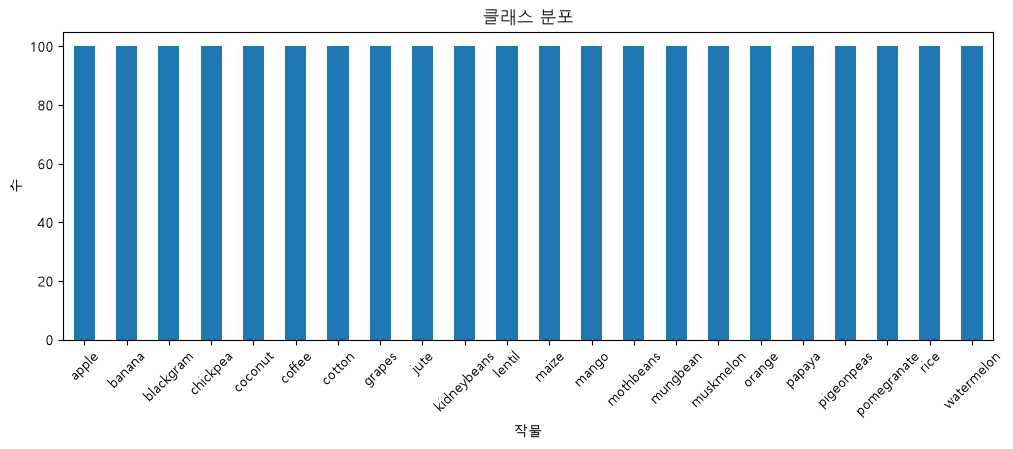

In [306]:
class_counts.plot(kind='bar', figsize=(12, 4))

plt.xlabel('작물')
plt.ylabel('수')
plt.title('클래스 분포')

plt.xticks(rotation=45)  # 작물 이름이 겹치지않게 45도 회전

plt.show()

In [307]:
# 라벨 인코딩 (0 ~ 클래스 수-1 정수로 변환)
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

label_mapping = pd.DataFrame({
    "class_index": range(len(label_encoder.classes_)),
    "crop": label_encoder.classes_
})

label_mapping

,class_index,crop
0,0,apple
1,1,banana
2,2,blackgram
3,3,chickpea
4,4,coconut
5,5,coffee
6,6,cotton
7,7,grapes
8,8,jute
9,9,kidneybeans


3. 학습 / 검증 / 테스트 데이터 분리
    - 70 : 15 : 15

In [308]:
# 학습과 나머지 데이터를 7:3 (각 작물 클래스 비율 유지) . 랜덤 시드 적용
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_encoded,
    test_size = 0.3,
    stratify = y_encoded,
    random_state = SEED
)

# 검증과 테스트 데이터를 5:5 (새로 나눈 y값 비율 유지). 랜덤 시드 적용
X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp, y_temp,
    test_size = 0.5,
    stratify = y_temp,
    random_state = SEED
)

print(X_train.shape, X_valid.shape, X_test.shape)
print(y_train.shape, y_valid.shape, y_test.shape)

(1540, 7) (330, 7) (330, 7)
(1540,) (330,) (330,)


In [309]:
# 입력 특성 표준화
scaler = StandardScaler() # 표준화 객체 생성

X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)
X_test_scaled = scaler.transform(X_test)

print(X_train.mean().round(4))
print(np.round(X_train_scaled.mean(axis=0), 4))

n               50.4558
p               53.2922
k               48.1286
temperature     25.5831
humidity        71.4399
ph               6.4698
rainfall       103.3550
dtype: float64
[ 0.  0.  0.  0. -0. -0. -0.]


4. Pytorch Dataset과 DataLoader 활용하여 미니배치 학습 준비

In [310]:
X_train_tensor = torch.tensor(X_train_scaled, dtype = torch.float32)
y_train_tensor = torch.tensor(y_train, dtype = torch.long)
X_valid_tensor = torch.tensor(X_valid_scaled, dtype = torch.float32)
y_valid_tensor = torch.tensor(y_valid, dtype = torch.long)
X_test_tensor = torch.FloatTensor(X_test_scaled)
y_test_tensor = torch.FloatTensor(y_test)


print(X_train_tensor.size(), y_train_tensor.size())
print(X_valid_tensor.size(), y_valid_tensor.size())
print(X_test_tensor.size(), y_test_tensor.size())

torch.Size([1540, 7]) torch.Size([1540])
torch.Size([330, 7]) torch.Size([330])
torch.Size([330, 7]) torch.Size([330])


In [311]:
# TensorDataset / DataLoader 활용하여 미니배치 생성

# 입력 텐서와 정답 텐서를 하나의 Dataset으로 묶기
train_dataset = TensorDataset(X_train_tensor,y_train_tensor)
valid_dataset = TensorDataset(X_valid_tensor,y_valid_tensor)
test_dataset = TensorDataset(X_test_tensor,y_test_tensor)

BATCH_SIZE = 64

# DataLoader로 미니배치 학습 준비 (학습만 shuffle=True)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"학습 배치 수: {len(train_loader)}")
print(f"검증 배치 수: {len(valid_loader)}")
print(f"테스트 배치 수: {len(test_loader)}")

학습 배치 수: 25
검증 배치 수: 6
테스트 배치 수: 6


이진 분류 BCEwithLogitsLoss -> 모델 출력 설정에 따라(N) 또는 (N,1)  
다중 분류 CrossEntropyLoss -> 출력 (N) long  
회귀 : MSELoss -> (N,1)float34

### 5. 딥러닝 모델 성능 고도화 전략  
- 기본 모델 vs 고도화 모델 성능비교
    - 입력값 표준화
    - 은닉층 확장
    - batch Normalzation : 은닉층 출력 분포 수치 안정
    - Dropout : 알부 뉴런 비활성화 -> 과적합 완화
    - Weight Decay : 가중치 폭주 억제
    - Label Smoothing : 정답  확신 완화
    - Learning Rate Scheduler : 개선없을시 학습률 감소
    - Gradient Clipping : 기울기 폭주 억제
    - Early Stopping : 개선없을시 학습 종료
    - Best Model Restore

### 6. 학습 및 검증 함수

In [312]:
# data_loader에 대한 손실, 정확도, 예측값 계산하는 함수
def evaluate_model(model,data_loader, criterion):
    model.eval()    # 평가 모드(Dropout 비활성화, Batch Normalization도 학습된 평균, 분산 사용)

    total_loss = 0

    # 전체 정답, 예측 클래스, 클래스별 확
    all_targets = []    
    all_predictions = []
    all_probabilities = []

    with torch.no_grad():
        for batch_X,batct_y in data_loader:
            batch_X = batch_X.to(device)
            batch_y = batct_y.to(device).long()

            logits = model(batch_X)     # 순전파 : 클래스별 점수 계산
            loss = criterion(logits, batch_y)  # 예측 점수와 실제 정답을 비교해서 손실 계산

            total_loss += loss.item() * batch_X.size(0) # 전체 손실 : 미니배치 전체 손실 * 미니배치 샘플 

            probabilities = torch.softmax(logits, dim=1)    # 클래스별 확률값 계산
            predictions = probabilities.argmax(dim=1)       # 가장 높은 클래스 번호

            # extend로 정답과 예측클래스, 확률값을 하나의 리스트에 요소로써 더해
            all_targets.extend(batch_y.cpu().numpy())       
            all_predictions.extend(predictions.cpu().numpy())
            all_probabilities.extend(probabilities.cpu().numpy())

    averaget_loss = total_loss / len(data_loader.dataset)   # totalloss를 전체 샘플수로 나눠 평균손실 계산

    accuracy = accuracy_score(all_targets,all_predictions)  

    # numpy 배열 형태로 변환해서 반환
    return (
        averaget_loss,accuracy,
        np.array(all_targets),np.array(all_predictions),np.array(all_probabilities)
    )

In [313]:
# 학습 및 검증 진행 함

def train_model(model,train_loader,valid_loader,criterion,optimizer,
                epochs=100,patience=15,scheduler=None,gradient_clip=None):


    history = {
        'train_loss':[],
        'valid_loss':[],
        'train_accuracy':[],
        'valid_accuracy':[],
        'lr':[],
    } 

    best_valid_loss = float('inf')  # 최저 검증 손실 초기화
    best_model_state = None         # 최고 성능 모델

    patience_count = 0  # valid_loss 개선 없는 연속 에포크 수

    for epoch in tqdm(range(1,epochs+1)):
        model.train()   # 학습 모드 (Dropout 활성화 / Batch Normalization 현재의 미니배치 통계 사용)

        total_train_loss = 0.0  # 현재 epoch의 학습 손실

        # 정확도 계싼용 정답과 예측값
        train_targets = []
        train_predictions = []

        for batch_X,batct_y in train_loader:
            batch_X = batch_X.to(device)
            batct_y = batct_y.to(device)


            # 이전 미니배치에서 계산한 기울기 초기화
            optimizer.zero_grad()
            logits = model(batch_X) # 순전파 : 클래스별 점수 계산
            loss = criterion(logits,batct_y)   # 예측 점수와 실제 정답을 비교해서 손실 계산
            loss.backward()

            # 기울기 폭주 방지용 GC (기울기 최대 노름 제한)
            if gradient_clip is not None:
                nn.utils.clip_grad_norm_(
                    model.parameters(),
                    max_norm = gradient_clip
                )


            optimizer.step()  # 계산된 기울기로 가중치 업데이트
            
            total_train_loss += (loss.item() * batch_X.size(0)) # 현재 배치의 손실 누적

            predictions = logits.argmax(dim = 1) # 가장 높은 logits를 가진 클래스 예측값으로 선택

            train_targets.extend(batct_y.cpu().numpy())
            train_predictions.extend(predictions.detach().cpu().numpy())

        train_loss = total_train_loss / len(train_loader.dataset)  
        train_accuracy = accuracy_score(train_targets, train_predictions)   

        valid_loss,valid_accuracy,_,_,_ = evaluate_model(model, valid_loader, criterion)

        current_lr = optimizer.param_groups[0]['lr']

        history['train_loss'].append(train_loss)
        history['train_accuracy'].append(train_accuracy)
        history['valid_loss'].append(valid_loss)
        history['valid_accuracy'].append(valid_accuracy)
        history['lr'].append(current_lr)

        # Early Stopping
        if valid_loss < best_valid_loss:
            best_valid_loss = valid_loss

            best_model_state = copy.deepcopy(model.state_dict())

            patience_count = 0

        else: 
            patience_count += 1

        if scheduler is not None:
            scheduler.step(valid_loss)

        if epoch == 1 or epoch % 10 ==0:
            print(f"Epoch : {epoch:3d} | Train_Loss : {train_loss:.4f}, Valid_Loss : {valid_loss:.4f}, Train_Accuracy : {train_accuracy:.4f}, Valid_Accuracy : {valid_accuracy:.4f}, LR : {current_lr:.6f}")

        if patience_count > patience:
            print(f"Epoch : {epoch}에서 Early Stopping 동작함!")
            break

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    return history, best_valid_loss

In [314]:
# 모델에서 실제로 학습되는 파라미터의 총 개수
def count_parameters(model):
    return sum(
        # numel() : 텐서에 포함된 전체 원소 수
        parameter.numel() 
        for parameter in model.parameters() 
        if parameter.requires_grad # requires_grad = True : 학습 대상 파라미터
    )

# 테스트 데이터에서 주요 다중 클래스용 지표 계산하는 함수
def calculate_metrics(model,data_loader,criterion):
    loss,accuracy,targets,predictions,probabilities = evaluate_model(model,data_loader,criterion)

    metrics = {
        "Loss" : loss,
        "Accuracy" : accuracy,
        # marco : 각 클래스의 점수를 동일한 비중으로 평균
        "Macro Precision" : precision_score(targets,predictions,average="macro",zero_division=0),
        "Macro Recall" : recall_score(targets,predictions,average="macro",zero_division=0),
        # weighted : 클래스별 데이터 수를 반영해서 적용
        "Weighted F1-Score" : f1_score(targets,predictions,average="weighted",zero_division=0),
    }

    return metrics,targets,predictions,probabilities

### 7. 기본 모델 학습
- 은닉층 64 -> 32
- 활성화 함수 ReLU
- 최적화 함수 Adam

In [315]:
input_size = X_train_tensor.size(1)
num_classes = len(label_encoder.classes_)
print(f"입력 특성 수 : {input_size} / 출력 클래스 수 : {num_classes}")

입력 특성 수 : 7 / 출력 클래스 수 : 22


In [316]:
# 기본 MLP 모델
class BaselineMLP(nn.Module):
    def __init__(self,input_size,num_classes):
        super().__init__() # 상속받은 모듈 초기화

        self.network = nn.Sequential(
            nn.Linear(input_size,64), # 입력층 7 -> 은닉층 64
            nn.ReLU(), # 비선형성 추가

            nn.Linear(64,32), # 은닉층 1 64 -> 은닉층 2 32
            nn.ReLU(), # 비선형성 추가

            nn.Linear(32,num_classes) # 은닉층 2 34 -> 출력층 : 22개 클래스에 대한 logits(원시 확률) 출력
        )

    def forward(self,x):
        return self.network(x)

baseline_model = BaselineMLP(input_size= input_size,num_classes=num_classes).to(device)

print(baseline_model)
print(f"학습 가능한 파라미터의 수 : {count_parameters(baseline_model)}")

BaselineMLP(
  (network): Sequential(
    (0): Linear(in_features=7, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=22, bias=True)
  )
)
학습 가능한 파라미터의 수 : 3318


In [317]:
baseline_criterion = nn.CrossEntropyLoss()

baseline_optimizer = torch.optim.Adam(baseline_model.parameters(),lr = 0.001)

baseline_history, baseline_best_valid_loss = train_model(
    model = baseline_model,
    train_loader = train_loader,
    valid_loader = valid_loader,
    criterion = baseline_criterion,
    optimizer = baseline_optimizer,
    epochs=100,
    patience=15,
)

print(f"기존 모델 최저 검증 손실 : {baseline_best_valid_loss:.4f}")

  0%|          | 0/100 [00:00<?, ?it/s]

Epoch :   1 | Train_Loss : 3.0077, Valid_Loss : 2.8970, Train_Accuracy : 0.1286, Valid_Accuracy : 0.2636, LR : 0.001000


 14%|█▍        | 14/100 [00:00<00:02, 31.46it/s]

Epoch :  10 | Train_Loss : 0.5043, Valid_Loss : 0.4643, Train_Accuracy : 0.9000, Valid_Accuracy : 0.9061, LR : 0.001000


 22%|██▏       | 22/100 [00:00<00:02, 28.60it/s]

...

Epoch :  80 | Train_Loss : 0.0391, Valid_Loss : 0.0440, Train_Accuracy : 0.9870, Valid_Accuracy : 0.9879, LR : 0.001000


 93%|█████████▎| 93/100 [00:03<00:00, 31.12it/s]

Epoch :  90 | Train_Loss : 0.0466, Valid_Loss : 0.0381, Train_Accuracy : 0.9825, Valid_Accuracy : 0.9848, LR : 0.001000


100%|██████████| 100/100 [00:03<00:00, 30.05it/s]

Epoch : 100 | Train_Loss : 0.0308, Valid_Loss : 0.0339, Train_Accuracy : 0.9890, Valid_Accuracy : 0.9879, LR : 0.001000
기존 모델 최저 검증 손실 : 0.0298


### 9. 모델 고도화 
- 은닉층 확장
- Batch Normalization
- Dropout
- AdamW
- label Smoothing
- Scheduler : ReduceLROnPlateau
- Gradient Clipping

In [318]:
# 기본 MLP 모델
class ImprovedMLP(nn.Module):
    def __init__(self,input_size,num_classes):
        super().__init__() # 상속받은 모듈 초기화

        self.network = nn.Sequential(
            nn.Linear(input_size,128), # 입력층 7 -> 은닉층 128
            nn.BatchNorm1d(128),    # 미니배치 단위로 출력 분포를 정규화 => 학습 안정
            nn.ReLU(), # 비선형성 추가

            nn.Dropout(0.3),    # 학습시 뉴런 30% 무작위로 비활성화

            nn.Linear(128,64), # 은닉층 1 128 -> 은닉층 2 64
            nn.BatchNorm1d(64),
            nn.ReLU(), # 비선형성 추가

            nn.Dropout(0.2),

            nn.Linear(64,32), # 은닉층 1 64 -> 은닉층 2 32
            nn.ReLU(), # 비선형성 추가


            nn.Linear(32,num_classes) # 은닉층 2 34 -> 출력층 : 22개 클래스에 대한 logits(원시 확률) 출력
        )

    def forward(self,x):
        return self.network(x)

improved_model = ImprovedMLP(input_size= input_size,num_classes=num_classes).to(device)

print(improved_model)
print(f"학습 가능한 파라미터의 수 : {count_parameters(improved_model)}")

ImprovedMLP(
  (network): Sequential(
    (0): Linear(in_features=7, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): ReLU()
    (10): Linear(in_features=32, out_features=22, bias=True)
  )
)
학습 가능한 파라미터의 수 : 12470


In [319]:
# Label Smoothing : 정답 클래스 대한 확신을 5% 줄임 => 일반화 성능 향상

improved_criterion = nn.CrossEntropyLoss(label_smoothing= 0.05)

# AdamW weigh_decay : 가중치가 지나치게 커지는 것을 억제
improved_optimizer = torch.optim.AdamW(improved_model.parameters(),lr = 0.001,weight_decay=0.0001)

sceduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    improved_optimizer, 
    mode = 'min',   # 검증 손실 기준 작아지는 방향을 개선으로 판단
    factor = 0.5,   # 학습률은 절반으로 감소
    patience = 5,   # 5회 동안 개선 없으면 학습률 감소
    min_lr = 1e-5   # 학습률 최소값
)

improved_history, improved_best_valid_loss = train_model(
    model = improved_model,
    train_loader = train_loader,
    valid_loader = valid_loader,
    criterion = improved_criterion,
    optimizer = improved_optimizer,
    epochs=1000,
    patience=15,
    scheduler= sceduler,
    gradient_clip= 1.0  # 기울기 노름을 최대 1로 제한 : 기울기 폭주 제한
)

print(f"고도화 모델 최저 검증 손실 : {improved_best_valid_loss:.4f}")

  0%|          | 2/1000 [00:00<01:02, 16.05it/s]

Epoch :   1 | Train_Loss : 2.9165, Valid_Loss : 2.7032, Train_Accuracy : 0.1766, Valid_Accuracy : 0.5152, LR : 0.001000


  1%|          | 12/1000 [00:00<01:14, 13.35it/s]

Epoch :  10 | Train_Loss : 0.7857, Valid_Loss : 0.5957, Train_Accuracy : 0.8883, Valid_Accuracy : 1.0000, LR : 0.001000


  2%|▏         | 22/1000 [00:01<01:02, 15.60it/s]

...

Epoch :  70 | Train_Loss : 0.5070, Valid_Loss : 0.4153, Train_Accuracy : 0.9662, Valid_Accuracy : 0.9970, LR : 0.000250


  8%|▊         | 82/1000 [00:05<01:02, 14.68it/s]

Epoch :  80 | Train_Loss : 0.5062, Valid_Loss : 0.4150, Train_Accuracy : 0.9662, Valid_Accuracy : 0.9909, LR : 0.000250


  9%|▉         | 91/1000 [00:06<01:00, 15.00it/s]

Epoch :  90 | Train_Loss : 0.5071, Valid_Loss : 0.4145, Train_Accuracy : 0.9662, Valid_Accuracy : 0.9879, LR : 0.000063
Epoch : 92에서 Early Stopping 동작함!
고도화 모델 최저 검증 손실 : 0.4107


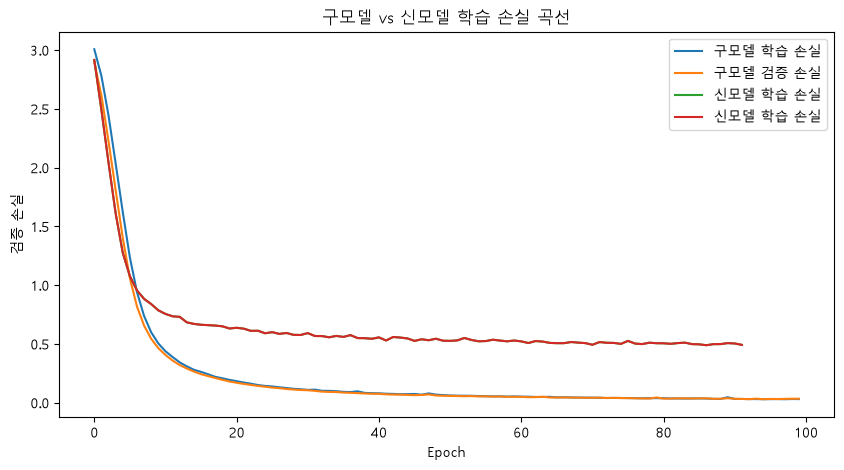

In [320]:
# 기존 모델과 고도화 모델 학습 및 검증 손실 비교 시각화

plt.figure(figsize = (10,5))

plt.plot(baseline_history['train_loss'], label='구모델 학습 손실')
plt.plot(baseline_history['valid_loss'], label='구모델 검증 손실')
plt.plot(improved_history['train_loss'], label='신모델 학습 손실')
plt.plot(improved_history['train_loss'], label='신모델 학습 손실')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('검증 손실')
plt.title('구모델 vs 신모델 학습 손실 곡선')
plt.show()

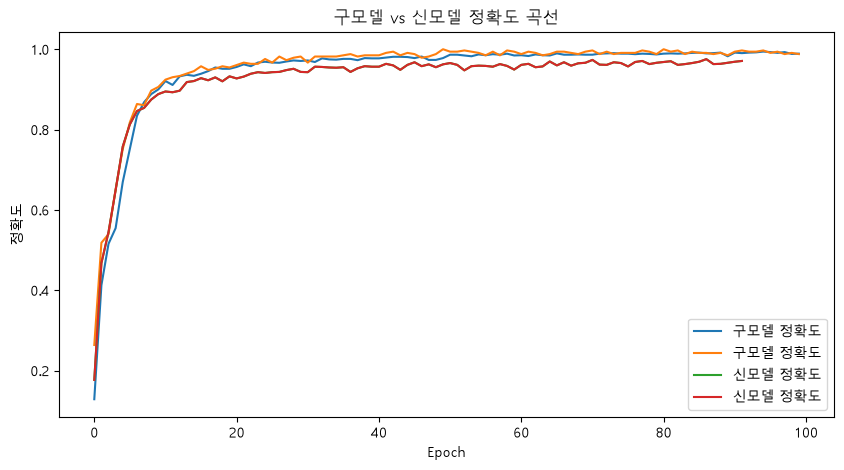

In [321]:
# 기존 모델과 고도화 모델 학습 및 정확도 비교 시각화

plt.figure(figsize = (10,5))

plt.plot(baseline_history['train_accuracy'], label='구모델 정확도')
plt.plot(baseline_history['valid_accuracy'], label='구모델 정확도')
plt.plot(improved_history['train_accuracy'], label='신모델 정확도')
plt.plot(improved_history['train_accuracy'], label='신모델 정확도')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('정확도')
plt.title('구모델 vs 신모델 정확도 곡선')
plt.show()

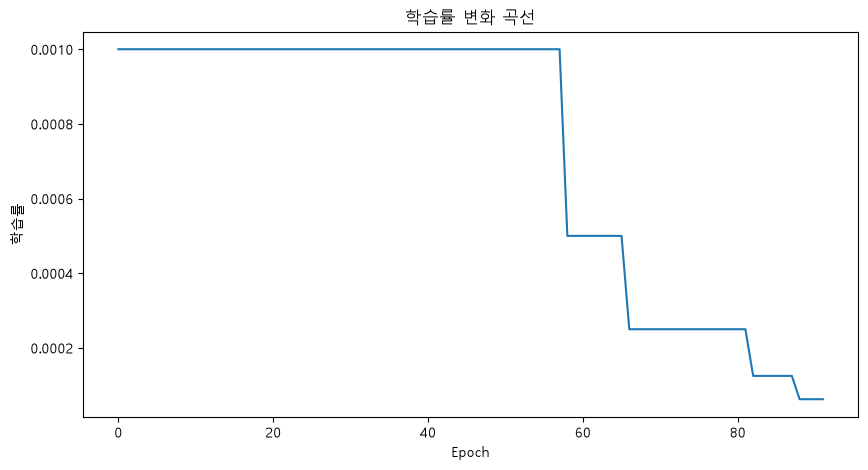

In [322]:
# 학습률 변화 시각화

plt.figure(figsize = (10,5))

plt.plot(improved_history['lr'],)
plt.xlabel('Epoch')
plt.ylabel('학습률')
plt.title('학습률 변화 곡선')
plt.show()

### 10. 테스트 데이터로 최종 평가

In [323]:
baseline_metrics , baseline_targets, baseline_predictions, baseline_probabilities = calculate_metrics(
    baseline_model,
    test_loader,
    baseline_criterion
)
improved_metrics , test_targets, test_predictions, test_probabilities = calculate_metrics(
    improved_model,
    test_loader,
    improved_criterion
)

comparison_df = pd.DataFrame({
    'Baseline Model' : baseline_metrics,
    'Improved Model' : improved_metrics
})

comparison_df.round(4)

,Baseline Model,Improved Model
Loss,0.0301,0.4144
Accuracy,0.9879,0.9909
Macro Precision,0.9890,0.9918
Macro Recall,0.9879,0.9909
Weighted F1-Score,0.9878,0.9909


loss는 떨어질 수 있어도 일반화 성능 향상 목적을 달성한 모습을 보임.

In [324]:
# 고도화 모델 클래스별 precision, recall, f1-score 보고서
report = classification_report(
    test_targets,
    test_predictions,
    labels= range(num_classes), # 0~ 전체 클래스 수 -1 평가
    target_names= label_encoder.classes_,   # 실제 작물 이름으로 표시
    output_dict= True,  # 딕셔너리 형태로 반환
    zero_division= 0    # 0으로 나누는 경우 오류가 아니라 0으로 처리
)

report_df = pd.DataFrame(report).T  # 전치해서 DataFrame으로 확인
report_df.round(4)

,precision,recall,f1-score,support
apple,1.0000,1.0000,1.0000,15.0000
banana,1.0000,1.0000,1.0000,15.0000
blackgram,1.0000,1.0000,1.0000,15.0000
chickpea,1.0000,1.0000,1.0000,15.0000
coconut,1.0000,1.0000,1.0000,15.0000
coffee,1.0000,1.0000,1.0000,15.0000
cotton,0.9375,1.0000,0.9677,15.0000
grapes,1.0000,1.0000,1.0000,15.0000
jute,0.8824,1.0000,0.9375,15.0000
kidneybeans,1.0000,1.0000,1.0000,15.0000


In [326]:
fig, ax = plt.subplot(figsize=(14,12))

ConfusionMatrixDisplay.from_predictions(
    test_targets,
    test_predictions,
    display_labels= label_encoder.classes_,
    xticks_rotation=45,
    cmap = 'Blues',
    colorbar= False,
    ax =ax
)

plt.title("혼동")

AttributeError: Axes.set() got an unexpected keyword argument 'figsize'

<Figure size 640x480 with 0 Axes>

### 11. 최적 모델과 전처리 도구 저장

In [ ]:
# 학습된 Pytorch 모델의 가중치와 모델 복원시 필요한 설정 저장
torch.save(
    {
        "model_state_dict" : improved_model.state_dict(),
        # 모델 구조 재구성시 필요한 입력과 출력 크기
        "input_size" : input_size,
        'num_classes' : num_classes,

        # 예측시 동일한 입력 순서 유지용 컬럼 목록
        'feature_columns' : feature_columns,

        # 클래스 번호를 작물 이름으로 복원하기 위한 클래스 목록
        'class_names' : label_encoder.classes_.tolist()
    },
    'crop_improved_model.pth'   # 저장 경로
)

# 학습시에 사용한 스케일러 저장
joblib.dump(scaler,'crop_scaler.pkl')
# 숫자 클래스와 작물 이름 변환 규칙 저장
joblib.dump(label_encoder,'crop_label_encoder.pkl')

print("모델 및 전처리 도구 저장 완료")

모델 및 전처리 도구 저장 완료


### 12. 새로운 샘플 데이터로 작물 추천받기

In [328]:
df.columns

Index(['n', 'p', 'k', 'temperature', 'humidity', 'ph', 'rainfall', 'label'], dtype='str')

In [330]:
# 여러가지 조건을 받아 적합한 작물 상위 n개를 추천하는 함수

def recommend_crop(n,p,k,temperature,humidity,ph,rainfall,top_k =3):
    sample = pd.DataFrame(
        [[n,p,k,temperature,humidity,ph,rainfall]]
    )

    # 학습된 형태로 표준화
    sample_scaled =scaler.transform(sample)

    # FloatTensor 형태 변환
    sample_tensor = torch.FloatTensor(sample_scaled).to(device)

    improved_model.eval()   # 평가 모드

    # 기울기 계산 안하는 상태
    with torch.no_grad():
        logits = improved_model(sample_tensor)  # logits 값 계산

        probabilities = torch.softmax(logits,dim=1)[0]  # 첫 번째 샘플에 대한 확률

    # topk() : 상위 k개의 확률, 인덱스 반환
    top_probabilities , top_indices = torch.topk(probabilities,k=top_k) 

    # 숫자로 인코딩된 클래스 번호를 실제 작물 이름으로 변환
    crobs = label_encoder.inverse_transform(top_indices.cpu().numpy())
    
    result = pd.DataFrame({
        'crob':crobs,
        'probability':(top_probabilities.cpu().numpy()*100).round(2)
    })

    return result

In [334]:
sample_row = df.iloc[0]

print(f"실제 작물 : {sample_row['label']}")

recommend_crop(
    n = sample_row['n'],
    p = sample_row['p'],
    k = sample_row['k'],
    temperature = sample_row['temperature'],
    humidity = sample_row['humidity'],
    ph = sample_row['ph'],
    rainfall = sample_row['rainfall'],
    top_k= 3
)


실제 작물 : rice


c:\Users\UK\SKN\model_validation\valid_venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


,crob,probability
0,rice,71.870003
1,jute,25.410000
2,chickpea,0.430000


In [333]:
sample_row

n                      90
p                      42
k                      43
temperature     20.879744
humidity        82.002744
ph               6.502985
rainfall       202.935536
label                rice
Name: 0, dtype: object

In [337]:
df.iloc[100]

n                     71
p                     54
k                     16
temperature      22.6136
humidity       63.690706
ph              5.749914
rainfall       87.759539
label              maize
Name: 100, dtype: object

In [338]:
recommend_crop(
    n = 65,
    p = 60,
    k = 20,
    temperature = 25,
    humidity = 70.3,
    ph = 4.3,
    rainfall = 100,
    top_k= 3
)


c:\Users\UK\SKN\model_validation\valid_venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


,crob,probability
0,pigeonpeas,67.919998
1,maize,23.820000
2,banana,1.700000
